## CUSTOMER CHURN PREDICTION

### EXPLORATORY DATA ANALYSIS

#### CARRIED OUT BY:
##### AYEVBOSA AJAYI - EBOHON - ayevbosaa0@gmail.com
##### SIYANBOLA OLUWATOBI ABIGAIL - siyanbolao910@gmail.com

### OVERVIEW

Customer churn is one of the more pressing problems banks deal with. When customers leave, it hits revenue hard, and the tricky part is that most institutions only notice after the fact. This notebook focuses on the Exploratory Data Analysis phase of the project, examining the dataset to understand its structure, distributions, and the key patterns that distinguish churners from loyal customers.

In [2]:
# importing the necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor

In [3]:
# loading the dataset

df = pd.read_csv('C:\\Users\\Hp\\Documents\\CPD\\Churn Modeling.csv')

#### DATASET OVERVIEW

In [4]:
# gives the dataset's size and dimensions

df.shape

(10000, 14)

In [5]:
# prints out the first 5 rows of the dataset

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
# Displays dataset structure including column names, data types, and null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [7]:
# this will give us the statistical summary of the numerical columns of the dataset
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
# Drop identifier columns that add no predictive value
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#### DATA QUALITY CHECKS

In [9]:
# Check for missing values across all columns
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

> From the output, the dataset contains no missing values across all columns, so no imputation or dropping of records is required.

In [10]:
# Check for zero values
# some may be valid (e.g. zero balance) while others could indicate missing or invalid data
(df == 0).sum()

CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure              413
Balance            3617
NumOfProducts         0
HasCrCard          2945
IsActiveMember     4849
EstimatedSalary       0
Exited             7963
dtype: int64

> Looking at the output, the zero values present in Tenure, Balance, HasCrCard, IsActiveMember, and Exited are not a cause for concern. They are all valid within this dataset, as a customer can genuinely have a zero balance, no credit card, or have just joined the bank.

#### TARGET VARIABLE EXPLORATION

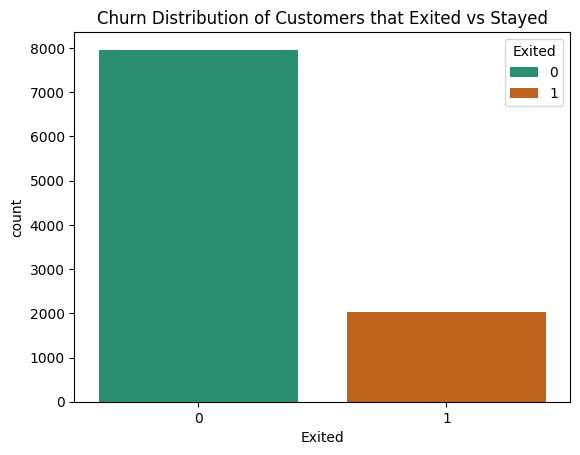

In [11]:
# this visualizes the difference between customers who stayed and customers who exited
sns.countplot(x='Exited', data=df, hue='Exited', palette='Dark2')
plt.title('Churn Distribution of Customers that Exited vs Stayed')
plt.show()

> From the plot, the dataset is clearly imbalanced. The majority of customers, around 8000, did not churn, while roughly 2000 did. This roughly 80/20 split is worth keeping in mind during modeling, as it can cause a classifier to be biased toward predicting the majority class.

In [12]:
# this will give us the percentage distribution of the exited column
counts = df['Exited'].value_counts(normalize=True) * 100
counts.index = ['Stayed', 'Left']
print(counts)

Stayed    79.63
Left      20.37
Name: proportion, dtype: float64


> Approximately 80% of customers remained with the bank, while 20% churned. This indicates a moderate churn rate, suggesting that retention focused initiatives could be valuable.

### DISTRIBUTION OF NUMERICAL FEATURES

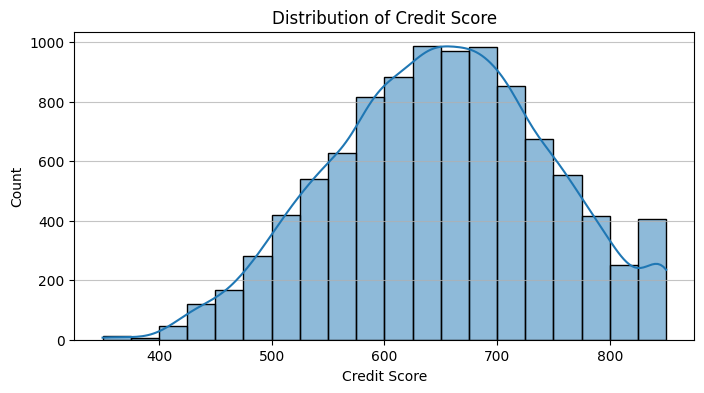

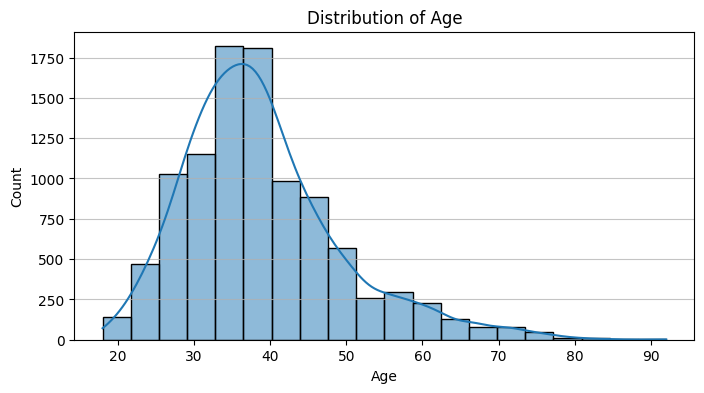

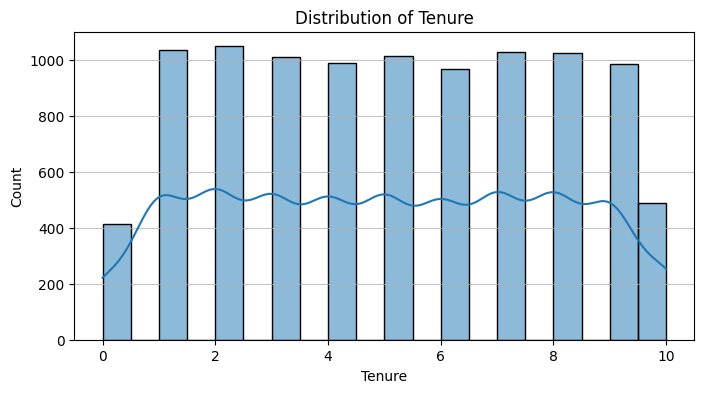

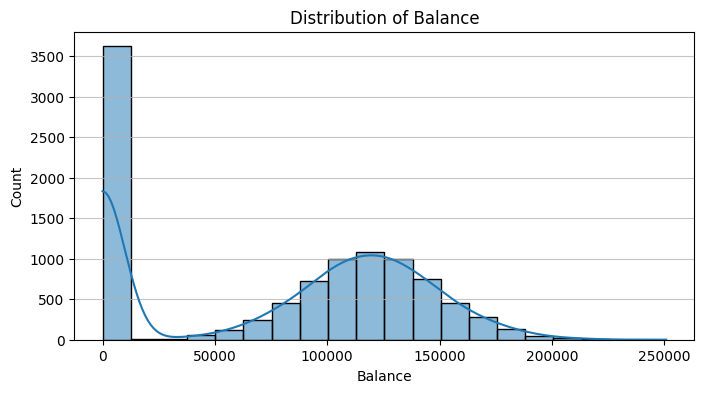

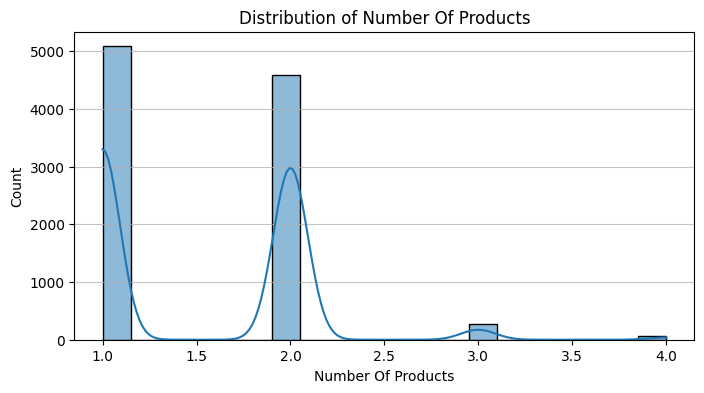

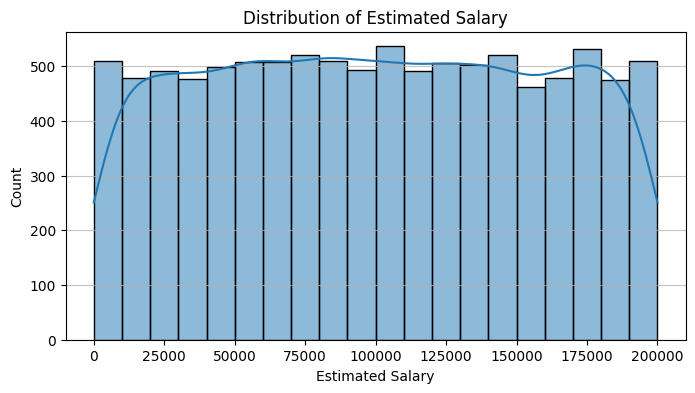

In [13]:
# Visualization of the distribution of the numerical features using histogram plots

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='CreditScore', kde=True, bins=20)
plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Age', kde=True, bins=20)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Tenure', kde=True, bins=20)
plt.title('Distribution of Tenure')
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Balance', kde=True, bins=20)
plt.title('Distribution of Balance')
plt.xlabel('Balance')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='NumOfProducts', kde=True, bins=20)
plt.title('Distribution of Number Of Products')
plt.xlabel('Number Of Products')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='EstimatedSalary', kde=True, bins=20)
plt.title('Distribution of Estimated Salary')
plt.xlabel('Estimated Salary')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

> CreditScore is roughly symmetric, which is fairly typical for a large customer base. Age skews slightly right, meaning the data leans more toward middle aged customers than younger ones. Tenure is evenly spread with no strong bias toward new or long standing accounts. Balance shows a bimodal pattern, a large concentration at zero and a separate cluster of higher value accounts, which is pretty common in retail banking. NumOfProducts is heavily skewed toward 1 and 2, with very few customers holding more than that. EstimatedSalary looks almost uniformly distributed, which suggests it could be synthetic or pre-binned. Nothing here demands immediate transformation, though the zero heavy Balance column is worth keeping in mind going into modeling.

### DISTRIBUTION OF NUMERICAL FEATURES AGAINST THE TARGET FEATURE

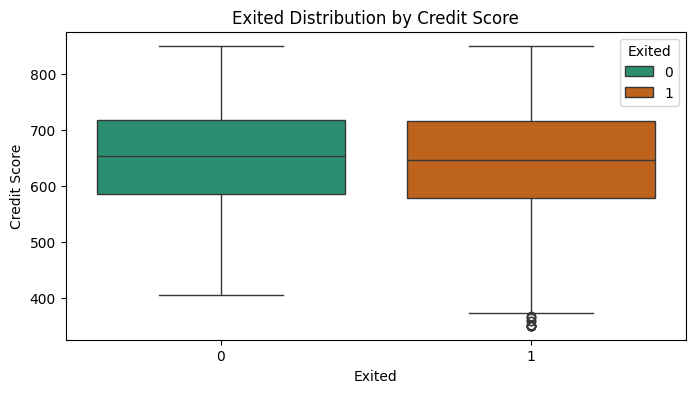

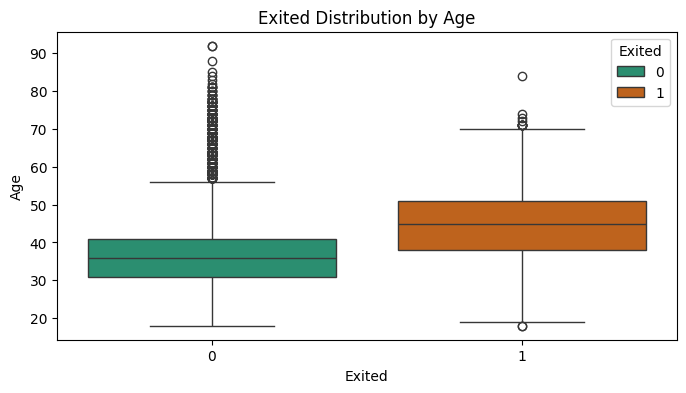

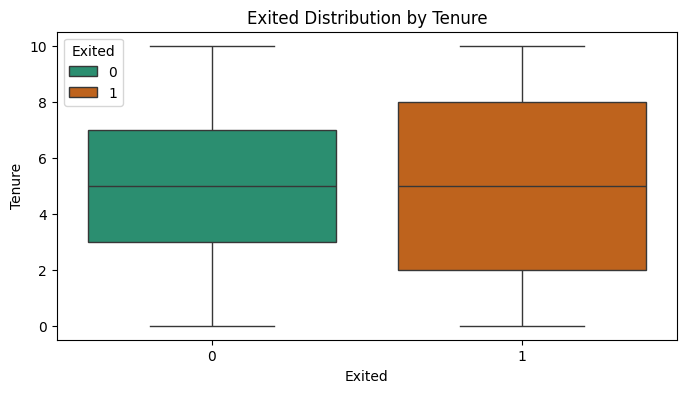

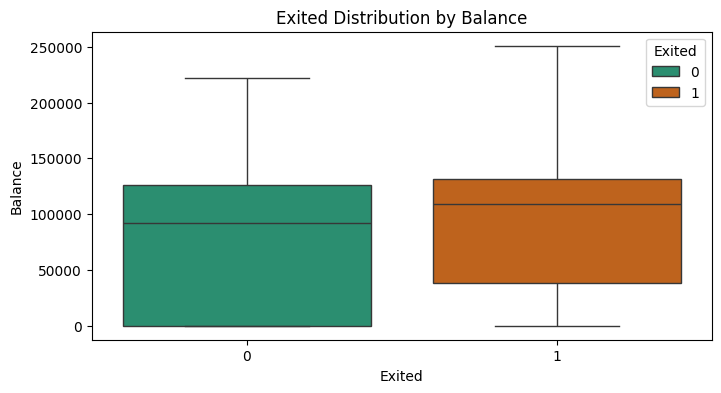

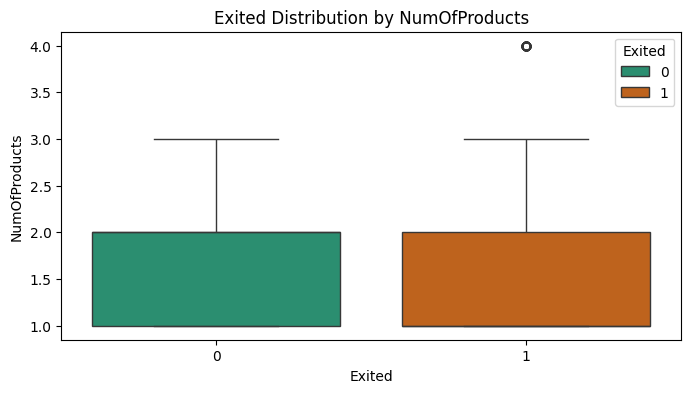

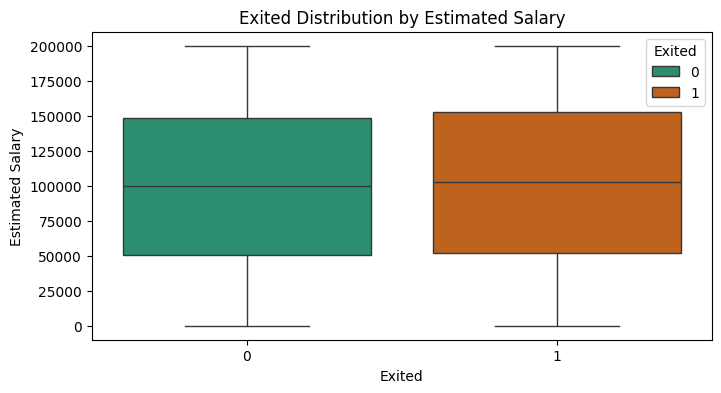

In [14]:
# Visualize the distribution of numerical features against the target variable using boxplots

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Exited', y='CreditScore', hue='Exited', palette='Dark2')
plt.title('Exited Distribution by Credit Score')
plt.xlabel('Exited')
plt.ylabel('Credit Score')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Exited', y='Age', hue='Exited', palette='Dark2')
plt.title('Exited Distribution by Age')
plt.xlabel('Exited')
plt.ylabel('Age')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Exited', y='Tenure', hue='Exited', palette='Dark2')
plt.title('Exited Distribution by Tenure')
plt.xlabel('Exited')
plt.ylabel('Tenure')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Exited', y='Balance', hue='Exited', palette='Dark2')
plt.title('Exited Distribution by Balance')
plt.xlabel('Exited')
plt.ylabel('Balance')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Exited', y='NumOfProducts', hue='Exited', palette='Dark2')
plt.title('Exited Distribution by NumOfProducts')
plt.xlabel('Exited')
plt.ylabel('NumOfProducts')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Exited', y='EstimatedSalary', hue='Exited', palette='Dark2')
plt.title('Exited Distribution by Estimated Salary')
plt.xlabel('Exited')
plt.ylabel('Estimated Salary')
plt.show()

### CATEGORICAL FEATURES DISTRIBUTION

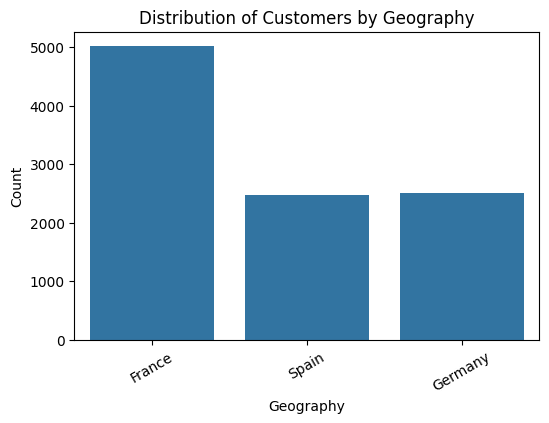

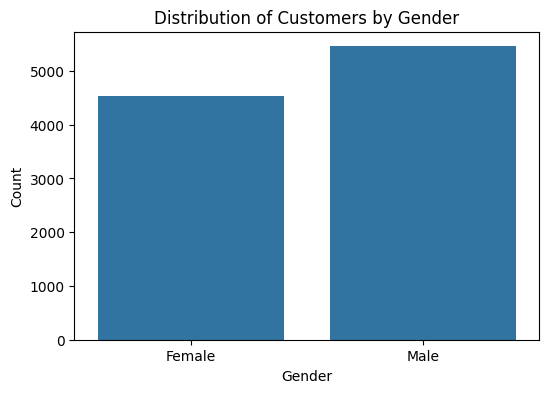

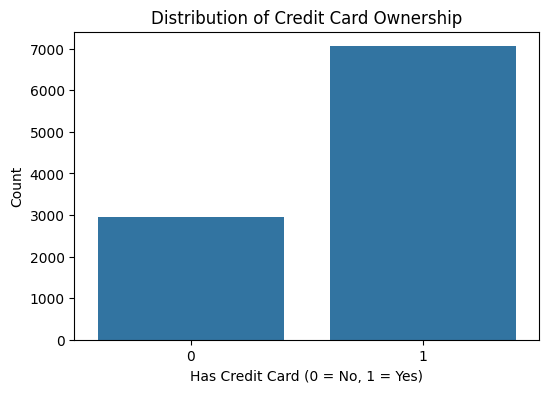

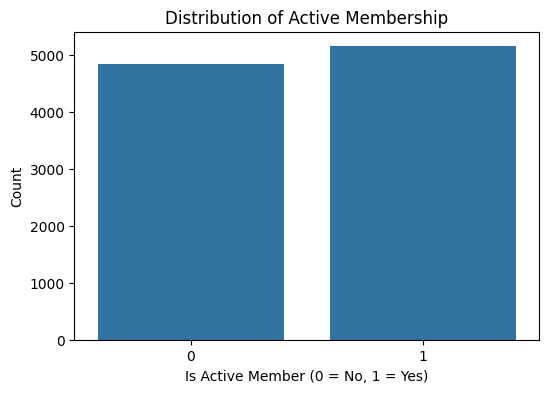

In [15]:
# Visualization of the distribution of the categorical features

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Geography')
plt.title('Distribution of Customers by Geography')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender')
plt.title('Distribution of Customers by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='HasCrCard')
plt.title('Distribution of Credit Card Ownership')
plt.xlabel('Has Credit Card (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='IsActiveMember')
plt.title('Distribution of Active Membership')
plt.xlabel('Is Active Member (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

> Most customers in the dataset are based in France, with Germany and Spain making up smaller shares. Gender is fairly balanced between male and female. The majority of customers hold a credit card, and a good portion are active members. Nothing here stands out as a severe imbalance worth worrying about.

#### DISTRIBUTION OF CATEGORICAL FEATURES AGAINST TARGET FEATURE

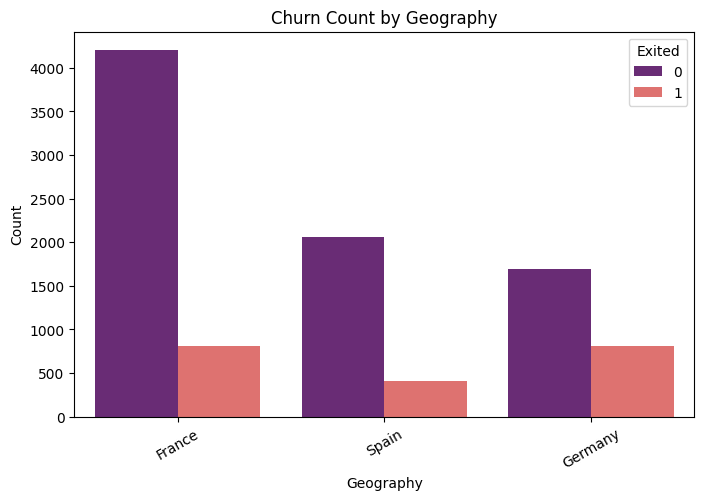

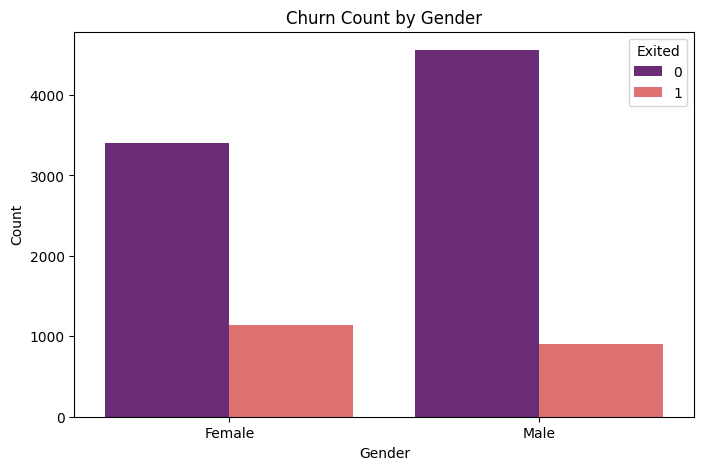

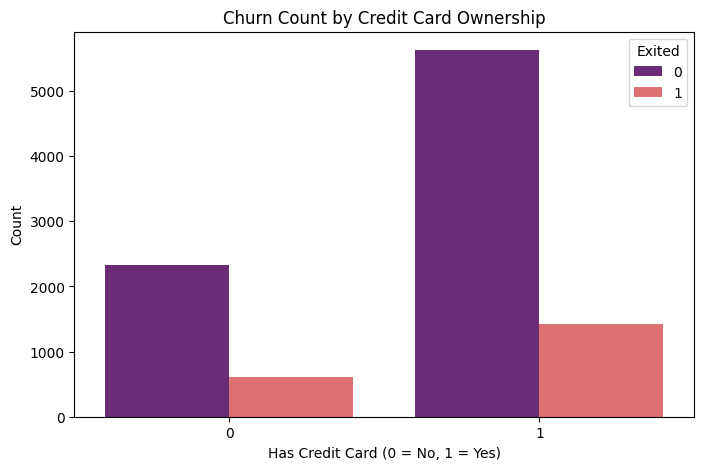

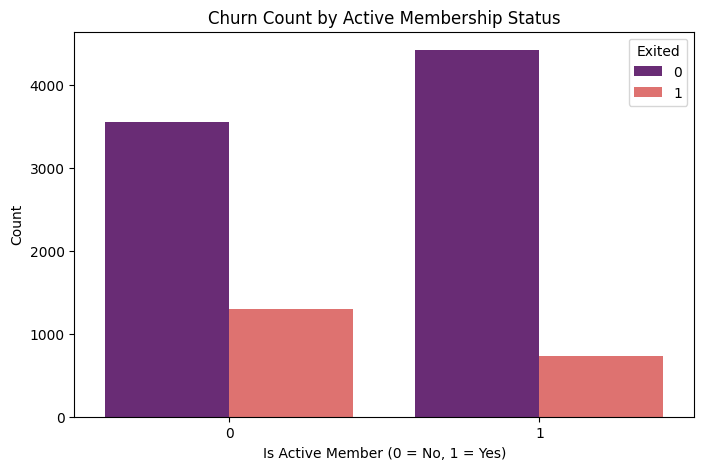

In [16]:
# Visualization of the distribution of the categorical features against the target feature

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Geography', hue='Exited', palette='magma')
plt.title('Churn Count by Geography')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Gender', hue='Exited', palette='magma')
plt.title('Churn Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='HasCrCard', hue='Exited', palette='magma')
plt.title('Churn Count by Credit Card Ownership')
plt.xlabel('Has Credit Card (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='IsActiveMember', hue='Exited', palette='magma')
plt.title('Churn Count by Active Membership Status')
plt.xlabel('Is Active Member (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

> There are some clear churn patterns within the categorical features. Germany has a notably higher churn rate compared to France and Spain. Gender on the other hand shows very little difference between male and female customers. Not having a credit card is linked to slightly higher churn, but the difference is not that significant. What stands out the most is that inactive members are far more likely to churn, pointing to customer engagement as one of the key factors in retention.

#### CORRELATION HEAT MAP

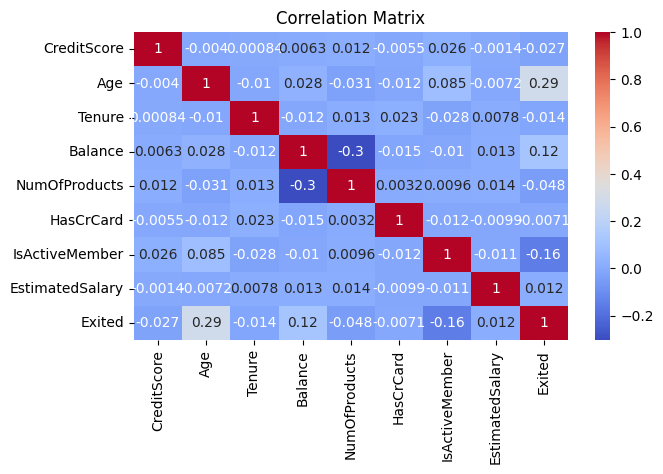

In [17]:
# This will allow us to identify features with strong correlation
# which will be helpful in understanding the relationship between the features

plt.figure(figsize=(7, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

> Most of the features show very weak correlations with each other, which is a good sign going into modeling since multicollinearity is not a major concern here. In terms of churn, Age has the most notable positive correlation at 0.29, so older customers are more likely to leave. IsActiveMember sits at -0.16, confirming that inactive customers churn more. Balance has a slight positive correlation with churn at 0.12. The -0.3 between Balance and NumOfProducts is the strongest inter-feature correlation in the matrix, but it is not alarming. Overall the features are reasonably independent.